In [129]:
import pandas as pd
import numpy as np
import nltk 
import os
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import sys
import torch
import seaborn as sns

In [102]:
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\amith\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [103]:
!{sys.executable} -m pip install transformers torch
from transformers import pipeline

Load Data

In [104]:
os.chdir(r'E:\ammi sentiment analysis')

In [105]:
df = pd.read_csv(r'archive\all-data.csv',names=['sentiment', 'headline'], encoding='latin-1')
df.head()

,sentiment,headline
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


### Run VADER Scoring

In [106]:
sia = SentimentIntensityAnalyzer()  

In [107]:
comp_scores=[]

for i in df['headline']:
    score = sia.polarity_scores(i)
    comp_scores.append(score['compound'])
    
print(f'Compund Scores: {comp_scores}')

df['vader_compound'] = comp_scores

df.head()

Compund Scores: [-0.128, -0.296, 0.0, 0.8555, 0.6705, 0.3485, 0.1531, 0.6124, 0.4404, 0.4404, 0.5574, 0.8176, 0.4939, 0.6124, 0.6124, 0.4215, 0.4939, 0.296, 0.0, 0.5267, 0.0, 0.4939, 0.5574, 0.0, 0.6124, 0.0, 0.6124, 0.7269, 0.7269, 0.7269, 0.4767, 0.4404, 0.0, 0.4939, 0.5719, 0.4404, 0.3182, 0.0, 0.2732, 0.0, 0.4404, 0.0, 0.2732, 0.2732, 0.0, 0.5994, 0.7351, 0.4939, 0.4019, 0.0, 0.4019, 0.743, 0.4939, 0.6486, 0.6808, 0.6705, 0.7506, 0.4939, 0.0, 0.0, 0.3612, 0.3182, 0.7506, 0.34, 0.296, 0.6597, 0.8455, 0.8779, 0.3182, 0.0, 0.0, 0.4336, 0.296, 0.7964, 0.743, 0.2732, 0.0, 0.0, 0.6597, 0.6597, 0.5267, 0.0, 0.0, 0.4939, 0.3034, -0.5267, 0.3626, 0.3804, 0.0, 0.2732, 0.7579, 0.0, 0.4404, 0.4404, 0.6124, 0.4404, 0.3182, 0.2732, 0.0, 0.7227, 0.7506, 0.2732, 0.2732, 0.0, 0.3818, 0.4404, 0.0, 0.4404, 0.2732, 0.0, 0.0, 0.0, 0.2732, 0.0772, 0.0, 0.4404, 0.6124, 0.6124, 0.4404, 0.4404, 0.4404, 0.3182, 0.0, 0.5994, 0.0, 0.0, 0.0, 0.1027, 0.4404, 0.3182, 0.5719, 0.6369, 0.2732, 0.0, 0.4404, 0.0, 0.5

,sentiment,headline,vader_compound
0,neutral,"According to Gran , the company has no plans t...",-0.1280
1,neutral,Technopolis plans to develop in stages an area...,-0.2960
2,negative,The international electronic industry company ...,0.0000
3,positive,With the new production plant the company woul...,0.8555
4,positive,According to the company 's updated strategy f...,0.6705


In [108]:
vad_label=[]

for i in comp_scores:
    if i>=0.05:
        vad_label.append('positive')
    elif i<=-0.05:
        vad_label.append('negative')
    else:
        vad_label.append('neutral') 
        
df['vader_label']=vad_label
df.head()

,sentiment,headline,vader_compound,vader_label
0,neutral,"According to Gran , the company has no plans t...",-0.1280,negative
1,neutral,Technopolis plans to develop in stages an area...,-0.2960,negative
2,negative,The international electronic industry company ...,0.0000,neutral
3,positive,With the new production plant the company woul...,0.8555,positive
4,positive,According to the company 's updated strategy f...,0.6705,positive


In [109]:
df['vader_label'].value_counts()

vader_label
positive    2398
neutral     2003
negative     445
Name: count, dtype: int64

In [110]:
df['sentiment'].value_counts()

sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64

In [111]:
#testing accuracy of vader against the test sentiment column

accu = accuracy_score(df.sentiment, df.vader_label)
print(accu)

0.5429219975237309


In [112]:
#create a confusion matrix
cm_1 = confusion_matrix(df.sentiment, df.vader_label)

cm_1_df = pd.DataFrame(cm_1, 
                     index=['actual_negative','actual_neutral','actual_positive'],
                     columns=['predicted_negative','predicted_neutral','predicted_positive'])

print(cm_1_df)

                 predicted_negative  predicted_neutral  predicted_positive
actual_negative                 180                185                 239
actual_neutral                  197               1487                1195
actual_positive                  68                331                 964


Insight for this prjoect: VADER (here) struggles with negative financial data. Gives a lot of false positives

### Use FinBERT

In [113]:
finbert = pipeline('text-classification', model='ProsusAI/finbert', batch_size=10)

loading configuration file config.json from cache at C:\Users\amith\.cache\huggingface\hub\models--ProsusAI--finbert\snapshots\4556d13015211d73dccd3fdd39d39232506f3e43\config.json
Model config BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "positive",
    "1": "negative",
    "2": "neutral"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "negative": 1,
    "neutral": 2,
    "positive": 0
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
loading configuration file config.json from cache at C:\Users\amith\.cache\huggingface\hub\models--ProsusAI--finbert\snapshots\4556d13015211d73dccd3fdd39d39232506f3e43\config.json
Model config BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "positive",
    "1": "negative",
    "2": "neutral"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  

In [114]:
finbert(df['headline'][0])

[{'label': 'neutral', 'score': 0.8857312798500061}]

In [115]:
print(torch.cuda.is_available())

False


In [116]:
headlines_list=df.headline.to_list()

fin_res=finbert(headlines_list)

In [123]:
print(fin_res[:5])

[{'label': 'neutral', 'score': 0.8857312798500061}, {'label': 'neutral', 'score': 0.5338403582572937}, {'label': 'negative', 'score': 0.9720560908317566}, {'label': 'positive', 'score': 0.9478998184204102}, {'label': 'positive', 'score': 0.8597080111503601}]


In [124]:
fin_scores=[]
for i in fin_res:
    fin_scores.append(i['score'])

print(f'FinBERT Scores: {fin_scores}')
df['finbert_score']=fin_scores
df

FinBERT Scores: [0.8857312798500061, 0.5338403582572937, 0.9720560908317566, 0.9478998184204102, 0.8597080111503601, 0.8735625743865967, 0.9481975436210632, 0.9570419788360596, 0.9524030685424805, 0.9550249576568604, 0.9371811151504517, 0.935117781162262, 0.8764341473579407, 0.9526545405387878, 0.9537839293479919, 0.9587922096252441, 0.9518005847930908, 0.9468708038330078, 0.9508934617042542, 0.951758623123169, 0.9466813802719116, 0.8042080998420715, 0.9560876488685608, 0.9523158073425293, 0.9558927416801453, 0.9495853781700134, 0.9569340348243713, 0.956375241279602, 0.9561133980751038, 0.9568637013435364, 0.8720378279685974, 0.9585705399513245, 0.9534754157066345, 0.9567638635635376, 0.9245228171348572, 0.9418976306915283, 0.9560031294822693, 0.9444364309310913, 0.9561483860015869, 0.9588885307312012, 0.9516132473945618, 0.9530863761901855, 0.7778818607330322, 0.9003238081932068, 0.9557326436042786, 0.9581224322319031, 0.9503067135810852, 0.8859901428222656, 0.9522870182991028, 0.9551

,sentiment,headline,vader_compound,vader_label,finbert_score,finbert_label
0,neutral,"According to Gran , the company has no plans t...",-0.1280,negative,0.885731,neutral
1,neutral,Technopolis plans to develop in stages an area...,-0.2960,negative,0.533840,neutral
2,negative,The international electronic industry company ...,0.0000,neutral,0.972056,negative
3,positive,With the new production plant the company woul...,0.8555,positive,0.947900,positive
4,positive,According to the company 's updated strategy f...,0.6705,positive,0.859708,positive
...,...,...,...,...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...,-0.7269,negative,0.970002,negative
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...,0.0000,neutral,0.974344,negative
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...,0.7430,positive,0.976724,negative
4844,negative,Net sales of the Paper segment decreased to EU...,0.4404,positive,0.974357,negative


In [125]:
fin_labels=[]
for i in fin_res:
    fin_labels.append(i['label'])

print(f'FinBERT Scores: {fin_labels}')
df['finbert_label']=fin_labels
df

FinBERT Scores: ['neutral', 'neutral', 'negative', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'negative', 'positive', 'positive', 'positive', 'positive', 'neutral', 'negative', 'positive', 'neutral', 'positive', 'positive', 'neutral', 'positive', 'positive', 'positive', 'positive', 'neutral', 'positive', 'neutral', 'neutral', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'neutral', 'positive', 'neutral

,sentiment,headline,vader_compound,vader_label,finbert_score,finbert_label
0,neutral,"According to Gran , the company has no plans t...",-0.1280,negative,0.885731,neutral
1,neutral,Technopolis plans to develop in stages an area...,-0.2960,negative,0.533840,neutral
2,negative,The international electronic industry company ...,0.0000,neutral,0.972056,negative
3,positive,With the new production plant the company woul...,0.8555,positive,0.947900,positive
4,positive,According to the company 's updated strategy f...,0.6705,positive,0.859708,positive
...,...,...,...,...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...,-0.7269,negative,0.970002,negative
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...,0.0000,neutral,0.974344,negative
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...,0.7430,positive,0.976724,negative
4844,negative,Net sales of the Paper segment decreased to EU...,0.4404,positive,0.974357,negative


In [120]:
#accuracy scores
accu_fin = accuracy_score(df.sentiment, df.finbert_label)
print(accu_fin)

0.8893933140734627


In [126]:
#create a confusion matrix
cm_2 = confusion_matrix(df.sentiment, df.finbert_label)

cm_2_df = pd.DataFrame(cm_2, 
                     index=['actual_negative','actual_neutral','actual_positive'],
                     columns=['predicted_negative','predicted_neutral','predicted_positive'])

print(cm_2_df)

                 predicted_negative  predicted_neutral  predicted_positive
actual_negative                 586                 11                   7
actual_neutral                  123               2469                 287
actual_positive                  22                 86                1255


### Comparision

In [128]:
print(f'VADER: \n {classification_report(df.sentiment,df.vader_label)}')
print(f'FinBERT: \n {classification_report(df.sentiment,df.finbert_label)}')

VADER: 
               precision    recall  f1-score   support

    negative       0.40      0.30      0.34       604
     neutral       0.74      0.52      0.61      2879
    positive       0.40      0.71      0.51      1363

    accuracy                           0.54      4846
   macro avg       0.52      0.51      0.49      4846
weighted avg       0.60      0.54      0.55      4846

FinBERT: 
               precision    recall  f1-score   support

    negative       0.80      0.97      0.88       604
     neutral       0.96      0.86      0.91      2879
    positive       0.81      0.92      0.86      1363

    accuracy                           0.89      4846
   macro avg       0.86      0.92      0.88      4846
weighted avg       0.90      0.89      0.89      4846



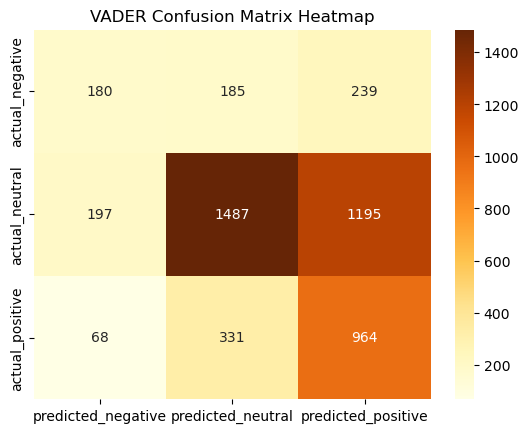

In [130]:
sns.heatmap(cm_1_df, annot=True, fmt='d',cmap='YlOrBr')
plt.title('VADER Confusion Matrix Heatmap')
plt.show()

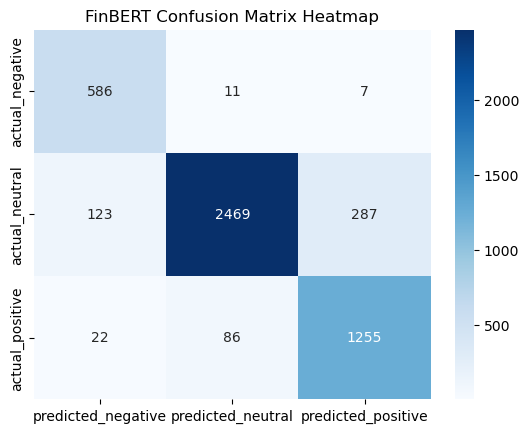

In [131]:
sns.heatmap(cm_2_df, annot=True, fmt='d',cmap='Blues')
plt.title('FinBERT Confusion Matrix Heatmap')
plt.show()